In [18]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATASET_DIR = Path("../../data/FineBio-Dataset")
ANNO_DIR = DATASET_DIR / "annotations/finebio_action_annotations"
VIDEO_DIR = DATASET_DIR / "videos/w640"
PROCESSED_DIR = DATASET_DIR / "processed"
PROCESSED_DIR.mkdir(exist_ok=True)

OUTPUT_JSONL = PROCESSED_DIR / "finebio_train.jsonl"
FRAME_METADATA = PROCESSED_DIR / "frames_to_extract.json"
OUTPUT_FRAMES = PROCESSED_DIR / "frames"  # For later extraction
OUTPUT_FRAMES.mkdir(exist_ok=True)

In [19]:
# Get annotation corresponding to each video
annotations = []
for txt in ANNO_DIR.glob("*.txt"):
    df = pd.read_csv(txt)
    df["video_id"] = txt.stem
    annotations.append(df)
full_df = pd.concat(annotations)

# Split sections
steps = full_df[full_df["task"].notna() & full_df["verb"].isna()].copy()
actions = full_df[full_df["verb"].notna()].copy()

# --- Preprocessing / Feature Engineering ---
# Calculate duration
actions["duration"] = actions["end_sec"] - actions["start_sec"]
# Extract protocol ID (e.g., '01' from 'P17_01_02')
actions["protocol"] = actions["video_id"].str.split("_").str[1]

Videos: 226
Total actions: 50659
Unique verbs: 10
Protocols: ['02' '04' '03' '01' '05' '07' '06']


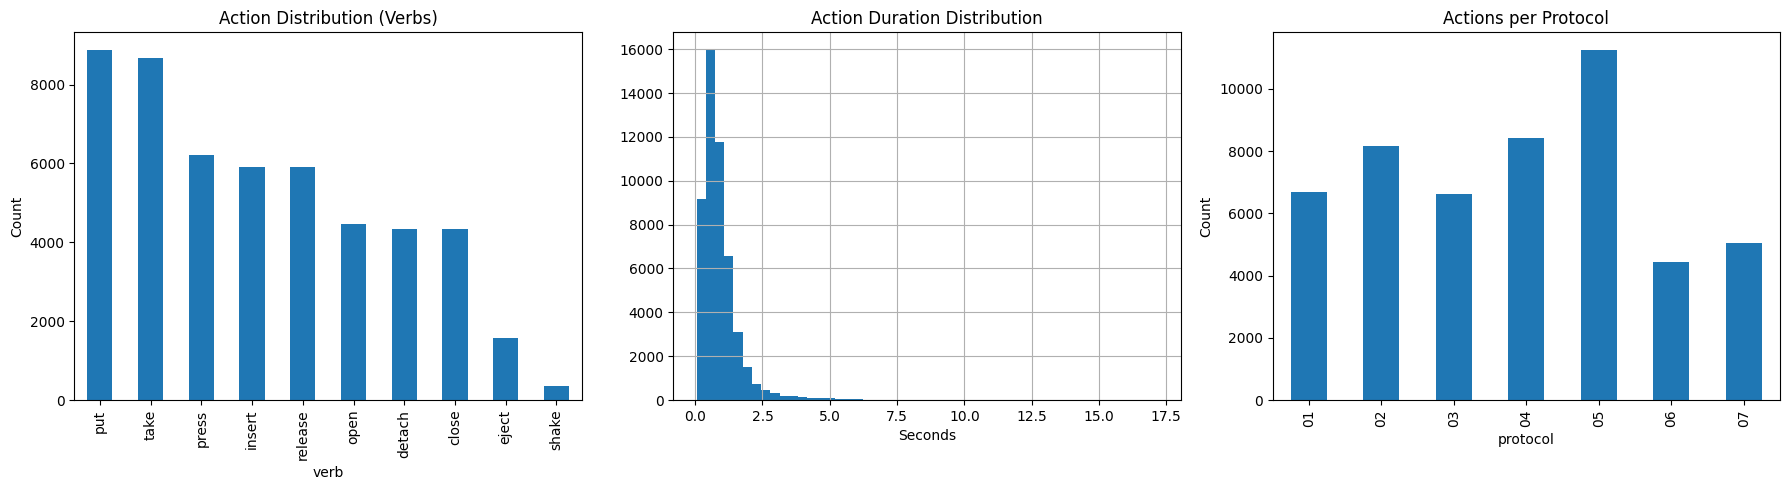

In [20]:
print(f"Videos: {len(annotations)}")
print(f"Total actions: {len(actions)}")
print(f"Unique verbs: {actions['verb'].nunique()}")
print(f"Protocols: {actions['video_id'].str.split('_').str[1].unique()}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Verb distribution
actions["verb"].value_counts().plot(
    kind="bar", ax=axes[0], title="Action Distribution (Verbs)"
)
axes[0].set_ylabel("Count")

# 2. Duration distribution
actions["duration"].hist(bins=50, ax=axes[1])
axes[1].set_title("Action Duration Distribution")
axes[1].set_xlabel("Seconds")

# 3. Protocol distribution
actions.groupby("protocol").size().plot(
    kind="bar", ax=axes[2], title="Actions per Protocol"
)
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [21]:
# Verb distribution
print(actions["verb"].value_counts())
print(actions["verb"].unique())

# Protocol distribution
print(actions.groupby("protocol").size())

# Duration stats
print("Duration")
print(actions["duration"].describe())

# Objects involved
print(f"Unique manipulated objects: {actions['manipulated_object'].nunique()}")
print(f"Unique affected objects: {actions['affected_object'].nunique()}")

# Check for missing affected_objects
print(f"Actions without affected_object: {actions['affected_object'].isna().sum()}")

verb
put        8881
take       8665
press      6221
insert     5915
release    5913
open       4468
detach     4345
close      4340
eject      1563
shake       348
Name: count, dtype: int64
['take' 'open' 'insert' 'press' 'release' 'put' 'detach' 'eject' 'shake'
 'close']
protocol
01     6701
02     8169
03     6636
04     8413
05    11258
06     4434
07     5048
dtype: int64
Duration
count    50659.000000
mean         0.914716
std          0.776064
min          0.050000
25%          0.470000
50%          0.740000
75%          1.110000
max         17.190000
Name: duration, dtype: float64
Unique manipulated objects: 27
Unique affected objects: 29
Actions without affected_object: 27290


Here is a cleaner, report-style output format that organizes the dataset statistics into logical sections (General, Verbs, Objects, Protocols, Duration, Quality) to help you make decisions about the data.



In [33]:
print("=" * 60)
print("FINEBIO DATASET SUMMARY")
print("=" * 60)

# General
n_videos = actions["video_id"].nunique()
n_actions = len(actions)
total_duration = actions["duration"].sum()

print("GENERAL:")
print(f"  • Videos processed:       {n_videos}")
print(f"  • Total actions:          {n_actions}")
print(
    f"  • Total footage duration: {total_duration / 60:.1f} min ({total_duration / 3600:.2f} hours)"
)

# Verbs
print("\nVERBS:")
print(f"  • Unique verbs:           {actions['verb'].nunique()}")
print("  • Top 15 verbs:")
print(
    "    " + actions["verb"].value_counts().head(15).to_string().replace("\n", "\n    ")
)

# Objects
print("\nOBJECTS:")
print(f"  • Unique manipulated:     {actions['manipulated_object'].nunique()}")
print(f"  • Unique affected:        {actions['affected_object'].nunique()}")
print("  • Top 5 manipulated objects:")
print(
    "    "
    + actions["manipulated_object"]
    .value_counts()
    .head(15)
    .to_string()
    .replace("\n", "\n    ")
)

# Protocols
print("\nPROTOCOLS:")
print(f"  • Unique protocols:       {actions['protocol'].nunique()}")
print("  • Actions per protocol:")
print("    " + actions.groupby("protocol").size().to_string().replace("\n", "\n    "))

# Duration
desc = actions["duration"].describe()
print("\nACTION DURATION (sec):")
print(f"  • Mean:   {desc['mean']:.2f}s")
print(f"  • Median: {desc['50%']:.2f}s")
print(f"  • Min:    {desc['min']:.2f}s")
print(f"  • Max:    {desc['max']:.2f}s")

# Data Quality
missing_affected = actions["affected_object"].isna().sum()
print("\nDATA QUALITY:")
print(
    f"  • Actions missing 'affected_object': {missing_affected} ({missing_affected / n_actions * 100:.1f}%)"
)

FINEBIO DATASET SUMMARY
GENERAL:
  • Videos processed:       226
  • Total actions:          50659
  • Total footage duration: 772.3 min (12.87 hours)

VERBS:
  • Unique verbs:           10
  • Top 15 verbs:
    verb
    put        8881
    take       8665
    press      6221
    insert     5915
    release    5913
    open       4468
    detach     4345
    close      4340
    eject      1563
    shake       348

OBJECTS:
  • Unique manipulated:     27
  • Unique affected:        29
  • Top 5 manipulated objects:
    manipulated_object
    yellow_pipette            13837
    micro_tube                 8130
    blue_pipette               6207
    8_channel_pipette          3243
    red_pipette                2935
    8_tube_stripes             2357
    tube_with_spin_column      1996
    cell_culture_plate         1846
    centrifuge                 1697
    8_tube_stripes_lid         1678
    yellow_tip_rack            1479
    cell_culture_plate_lid     1307
    50ml_tube            

We have stats on our data. Now we prepare the data processing

In [ ]:
def create_training_sample(action_row, step_name, video_path, clip_path):
    return {
        "video": str(clip_path),  # Path to the video clip
        "conversations": [
            {
                "role": "user",
                "content": [
                    {"type": "video", "video": str(clip_path)},
                    {"type": "text", "text": "Describe this laboratory action."},
                ],
            },
            {
                "role": "assistant",
                "content": [
                    {
                        "type": "text",
                        "text": f"Step: {step_name}\nAction: {action_row['verb']} {action_row['manipulated_object']}",
                    }
                ],
            },
        ],
    }


In [32]:
def estimate_tokens(width, height, duration_sec, fps):
    pixels = width * height
    patches_per_frame = pixels / 784
    frames = duration_sec * fps
    vision_tokens = patches_per_frame * frames
    total_tokens = vision_tokens + 75

    # Memory (GB)
    inference_vram = 7 + 0.5 + (total_tokens * 0.001)
    training_vram = 7 + ((0.5 + total_tokens * 0.001) * 1.5)

    return {
        "resolution": f"{width}x{height}",
        "fps": fps,
        "duration": duration_sec,
        "tokens": int(total_tokens),
        "inference_vram_gb": round(inference_vram, 1),
        "training_vram_gb": round(training_vram, 1),
        "Fits?": inference_vram < 32.0 and training_vram < 32.0,
    }


# Test
configs = [
    (1280, 720, 4, 2),
    (1280, 720, 4, 4),
    (1280, 720, 4, 8),
    (480, 640, 4, 2),
    (480, 640, 4, 4),
    (480, 640, 4, 8),
]

results = []
for w, h, d, fps in configs:
    res = estimate_tokens(w, h, d, fps)
    results.append(res)

df_results = pd.DataFrame(results)
display(df_results)

,resolution,fps,duration,tokens,inference_vram_gb,training_vram_gb,Fits?
0,1280x720,2,4,9479,17.0,22.0,True
1,1280x720,4,4,18883,26.4,36.1,False
2,1280x720,8,4,37691,45.2,64.3,False
3,480x640,2,4,3209,10.7,12.6,True
4,480x640,4,4,6344,13.8,17.3,True
5,480x640,8,4,12613,20.1,26.7,True
